# Seismic Traveltime Tomography

This notebook demonstrates **Adjoint-State Traveltime Tomography (ATT)** — a gradient-based method for recovering a 2D P-wave velocity model from first-arrival traveltimes.

Precomputed results are loaded from `evaluation/reference_outputs/` and `output/`, so this notebook **runs in seconds** without re-running the full inversion.

---
## Problem Setup

We work with a 2D Cartesian grid (111 × 26 nodes, 2 km spacing → 220 km × 50 km domain).  The true velocity model consists of **elliptical Gaussian anomalies** (±5%, σ_x ≈ 16.5 km, σ_z ≈ 7.5 km, aspect ratio 2.2:1) arranged in a 4 × 3 checkerboard pattern superimposed on a linear gradient background (6→8 km/s), representing continental crust from the upper crust to near the Moho.  1000 earthquake sources are distributed randomly throughout the domain (with higher density in the upper-left quadrant); 8 seismic stations record first arrivals at the surface.

The measurement equation is the **Eikonal equation**:

$$\left(\frac{\partial T}{\partial x}\right)^2 + \left(\frac{\partial T}{\partial z}\right)^2 = s^2(x,z)$$

where $s = 1/v$ is the slowness field and $T(x,z)$ is the first-arrival traveltime from a given source.  The inverse problem is to recover $s(x,z)$ from the measured traveltimes $T^{\rm obs}_{nm}$ (source $n$, receiver $m$).

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', '..'))

import numpy as np
import matplotlib.pyplot as plt
import json

# Task root (one level up from notebooks/)
TASK_ROOT = os.path.dirname(os.getcwd())
if 'notebooks' not in os.getcwd():
    TASK_ROOT = os.getcwd()

print('Task root:', TASK_ROOT)

Task root: /home/groot/Documents/PKUlab/imaging-101/tasks/seismic_traveltime_tomography


In [2]:
# ------------------------------------------------------------------
# Load data
# ------------------------------------------------------------------
raw   = np.load(os.path.join(TASK_ROOT, 'data', 'raw_data.npz'))
gt    = np.load(os.path.join(TASK_ROOT, 'data', 'ground_truth.npz'))
meta  = json.load(open(os.path.join(TASK_ROOT, 'data', 'meta_data.json')))

T_obs     = raw['traveltime_obs'][0]   # (1000, 8)
sources   = raw['sources'][0]          # (1000, 2)
receivers = raw['receivers'][0]        # (8, 2)
v_true    = gt['velocity'][0]          # (26, 111)

Nx, Nz = meta['Nx'], meta['Nz']
dx, dz = meta['dx_km'], meta['dz_km']
x_max  = meta['x_max_km']
z_max  = meta['z_max_km']

xs = np.arange(Nx) * dx
zs = np.arange(Nz) * dz

print(f'Grid: {Nx}\u00d7{Nz} nodes, spacing {dx} km  \u2192  {x_max} km \u00d7 {z_max} km')
print(f'Sources: {len(sources)}, Receivers: {len(receivers)}')
print(f'Observed traveltime range: {T_obs.min():.2f} \u2013 {T_obs.max():.2f} s')
print(f'True velocity range: {v_true.min():.3f} \u2013 {v_true.max():.3f} km/s')

Grid: 111×26 nodes, spacing 2.0 km  →  220.0 km × 50.0 km
Sources: 1000, Receivers: 8
Observed traveltime range: 0.08 – 28.51 s
True velocity range: 5.826 – 8.232 km/s


## 1. True Velocity Model and Acquisition Geometry

The true model is a **4 × 3 grid of elliptical Gaussian anomalies**: the linear background $v_{\rm bg}(z) = 6 + 2z/50$ km/s is multiplied by $(1 + \delta_v(x,z))$, where $\delta_v$ consists of alternating ±5% Gaussian blobs with $\sigma_x \approx 16.5$ km and $\sigma_z \approx 7.5$ km (aspect ratio 2.2:1).  The smooth-edged anomalies are more representative of real crustal heterogeneity than sharp rectangular blocks.

The upper-left source density bias reflects the real-world scenario where seismicity is concentrated in active fault zones, leaving parts of the domain poorly illuminated.

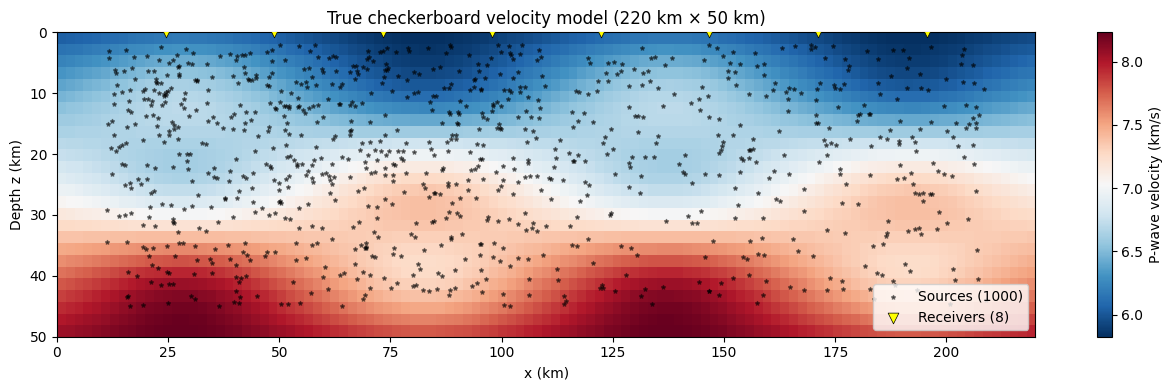

v_true range: 5.826 – 8.232 km/s
Surface receivers at x = [24.444445, 48.88889, 73.333336, 97.77778, 122.22222, 146.66667, 171.11111, 195.55556]


In [3]:
fig, ax = plt.subplots(figsize=(13, 4))
im = ax.imshow(v_true, extent=[0, x_max, z_max, 0],
               aspect='auto', cmap='RdBu_r',
               vmin=v_true.min(), vmax=v_true.max())
ax.scatter(sources[:, 0],   sources[:, 1],   s=8,  c='k',      marker='*', label='Sources (1000)',  zorder=5, alpha=0.5)
ax.scatter(receivers[:, 0], receivers[:, 1], s=60, c='yellow',  marker='v', label='Receivers (8)',   zorder=6, edgecolors='k', linewidths=0.5)
plt.colorbar(im, ax=ax, label='P-wave velocity (km/s)')
ax.set_xlabel('x (km)'); ax.set_ylabel('Depth z (km)')
ax.set_title('True checkerboard velocity model (220 km \u00d7 50 km)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f'v_true range: {v_true.min():.3f} \u2013 {v_true.max():.3f} km/s')
print(f'Surface receivers at x = {sorted(receivers[:,0])}')

## 2. Background Velocity Model

The inversion starts from a smooth 1D linear gradient:

$$v_{\rm bg}(z) = v_0 + (v_1 - v_0)\,\frac{z}{z_{\rm max}}$$

with $v_0 = 6.0$ km/s (surface, upper continental crust) and $v_1 = 8.0$ km/s (base at 50 km depth, near the Moho).  The goal is to recover the elliptical Gaussian perturbation $\delta v = v_{\rm true} - v_{\rm bg}$, which encodes the checkerboard-like lateral heterogeneity.

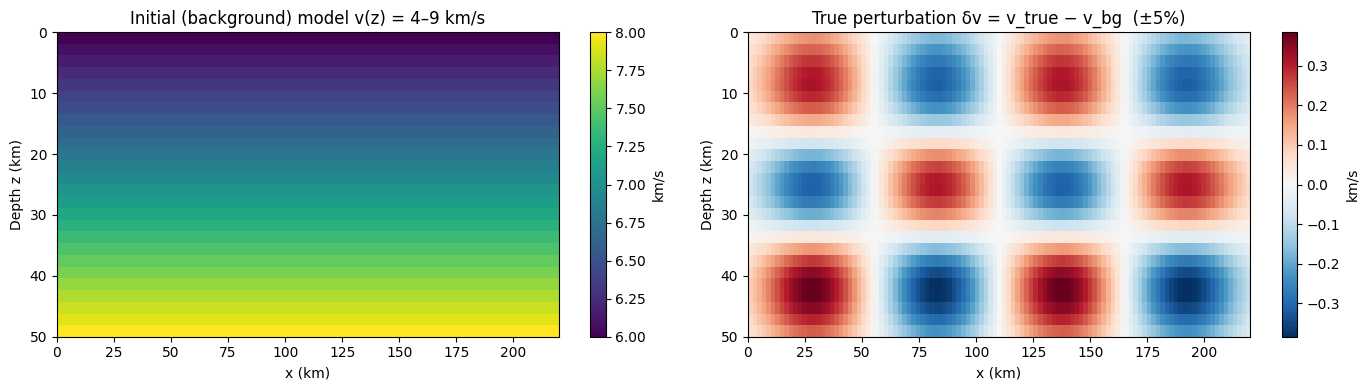

Background velocity range: 6.000 – 8.000 km/s
True perturbation range:   -0.384 – 0.384 km/s


In [4]:
import sys; sys.path.insert(0, TASK_ROOT)
from src.generate_data import make_background_velocity

v_bg    = make_background_velocity(Nx, Nz, dx, dz,
                                    meta['v0_km_s'], meta['v1_km_s'])
dv_true = v_true - v_bg

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (v, title, cmap) in zip(axes, [
    (v_bg,    'Initial (background) model v(z) = 4\u20139 km/s', 'viridis'),
    (dv_true, 'True perturbation \u03b4v = v_true \u2212 v_bg  (\u00b15%)', 'RdBu_r'),
]):
    vabs = np.abs(v).max() if 'perturbation' in title else None
    kwargs = dict(extent=[0, x_max, z_max, 0], aspect='auto', cmap=cmap)
    if vabs is not None:
        kwargs['vmin'] = -vabs; kwargs['vmax'] = vabs
    im = ax.imshow(v, **kwargs)
    plt.colorbar(im, ax=ax, label='km/s')
    ax.set_xlabel('x (km)'); ax.set_ylabel('Depth z (km)')
    ax.set_title(title)
plt.tight_layout()
plt.show()

print(f'Background velocity range: {v_bg.min():.3f} \u2013 {v_bg.max():.3f} km/s')
print(f'True perturbation range:   {dv_true.min():.3f} \u2013 {dv_true.max():.3f} km/s')

## 3. The ATT Algorithm

The inversion minimises the traveltime misfit

$$\chi(s) = \frac{1}{2}\sum_{n,m}\bigl(T^{\rm syn}_{nm}(s) - T^{\rm obs}_{nm}\bigr)^2$$

by iterating the following steps:

1. **Forward step** — solve the Eikonal equation from each source using the Fast Marching Method (FMM) → synthetic traveltimes $T^{\rm syn}_{nm}$
2. **Residuals** — $R_{nm} = T^{\rm syn}_{nm} - T^{\rm obs}_{nm}$
3. **Sensitivity kernel** — ray back-projection: for each receiver, trace a ray back to source along $-\nabla T / |\nabla T|$ using Euler integration; accumulate $R_{nm}\,\Delta\ell$ at each visited grid node to build $K_s$, and $\Delta\ell$ alone to build the coverage density kernel $K_d$
4. **Kernel density normalization** — $K_s \leftarrow K_s / (K_d + \varepsilon)^\zeta$ with $\zeta=0.5$, $\varepsilon=10^{-4}$
5. **Gaussian smoothing** of the normalized kernel ($\sigma = 4.0$ grid cells) for implicit regularization
6. **Slowness update** — $s \leftarrow s - \alpha K_s$ where the step size $\alpha$ is chosen so that $\max|\Delta s / s| = 2\%$; step size decays by $0.97\times$ each iteration

After 80 iterations the elliptical Gaussian anomalies are recovered with NCC ≈ 0.96 on the perturbation.

## 4. Precomputed Results

The full inversion (80 iterations, ≈5–10 min on CPU) was run in advance.  We load the saved output below.

In [5]:
ref    = np.load(os.path.join(TASK_ROOT, 'evaluation', 'reference_outputs', 'baseline_reference.npz'))
v_inv  = ref['velocity'][0]              # (26, 111)
dv_inv = ref['velocity_perturbation'][0] # (26, 111)

print(f'v_inv range: {v_inv.min():.3f} \u2013 {v_inv.max():.3f} km/s')
print(f'dv_inv range: {dv_inv.min():.3f} \u2013 {dv_inv.max():.3f} km/s')

v_inv range: 5.711 – 8.587 km/s
dv_inv range: -0.419 – 0.587 km/s


In [6]:
# Load precomputed metrics
metrics_out = json.load(open(os.path.join(TASK_ROOT, 'output', 'metrics.json')))
for k, val in metrics_out.items():
    print(f'  {k}: {val:.4f}')

  ncc_perturbation: 0.9558
  nrmse_perturbation: 0.0730
  ncc_full: 1.0000
  nrmse_full: 0.0233
  initial_misfit: 140.8473
  final_misfit: 41.0570
  misfit_reduction: 3.4305


## 5. Velocity Recovery

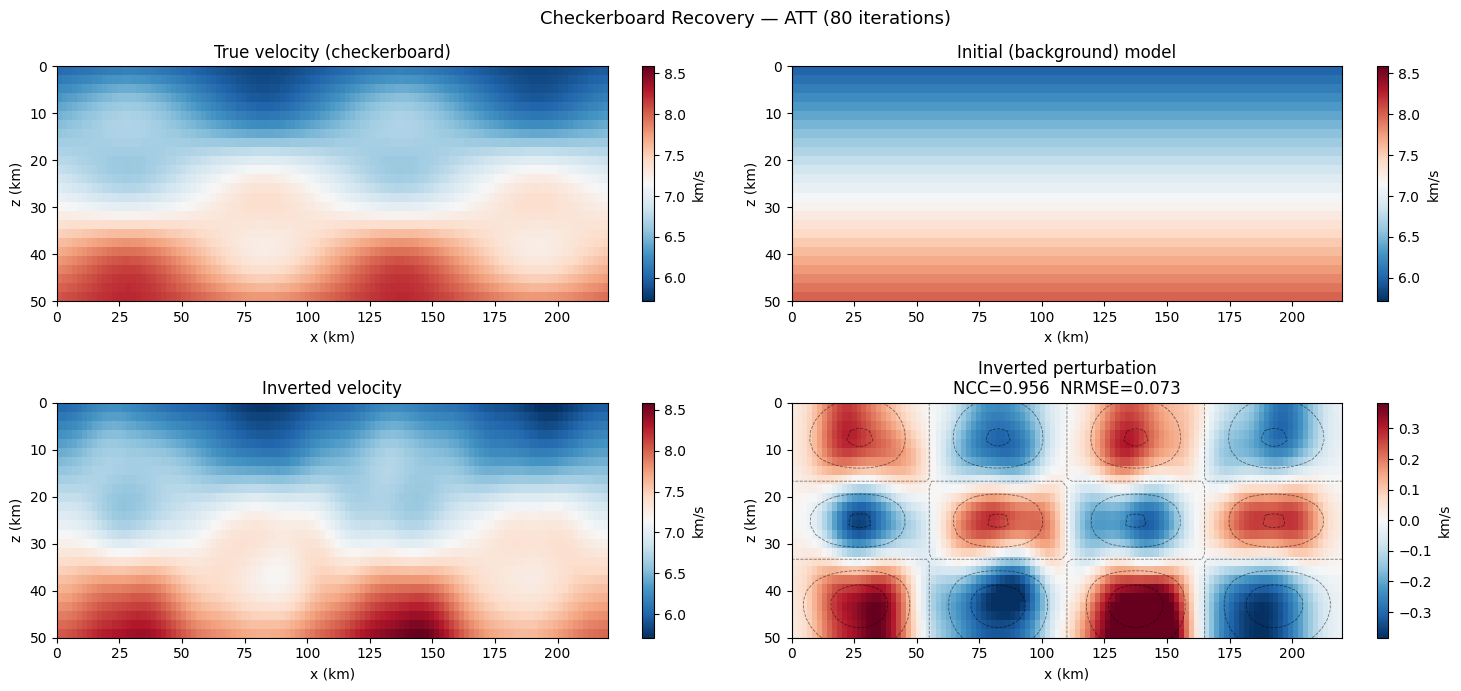

Dashed contours = true perturbation isolines


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 7))

vmin_vel = min(v_true.min(), v_inv.min())
vmax_vel = max(v_true.max(), v_inv.max())
vabs_dv  = np.abs(dv_true).max()

panels = [
    (v_true,  'True velocity (checkerboard)',   'RdBu_r', vmin_vel, vmax_vel),
    (v_bg,    'Initial (background) model',     'RdBu_r', vmin_vel, vmax_vel),
    (v_inv,   'Inverted velocity',              'RdBu_r', vmin_vel, vmax_vel),
    (dv_inv,  'Inverted perturbation',          'RdBu_r', -vabs_dv, vabs_dv),
]

for ax, (data, title, cmap, vmin, vmax) in zip(axes.flat, panels):
    im = ax.imshow(data, extent=[0, x_max, z_max, 0],
                   aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, label='km/s')
    ax.set_xlabel('x (km)'); ax.set_ylabel('z (km)')
    ax.set_title(title)

# Overlay true perturbation contours on the inverted perturbation panel
axes[1, 1].contour(xs, zs, dv_true, levels=5, colors='k', linewidths=0.6, linestyles='--', alpha=0.5)
axes[1, 1].set_title(
    f'Inverted perturbation\nNCC={metrics_out["ncc_perturbation"]:.3f}  '
    f'NRMSE={metrics_out["nrmse_perturbation"]:.3f}')

plt.suptitle('Checkerboard Recovery \u2014 ATT (80 iterations)', fontsize=13)
plt.tight_layout()
plt.show()

print('Dashed contours = true perturbation isolines')

## 6. True vs. Recovered Perturbation (Side by Side)

A direct comparison of $\delta v_{\rm true}$ and $\delta v_{\rm inv}$ on the same color scale shows how well the checkerboard pattern has been reconstructed.

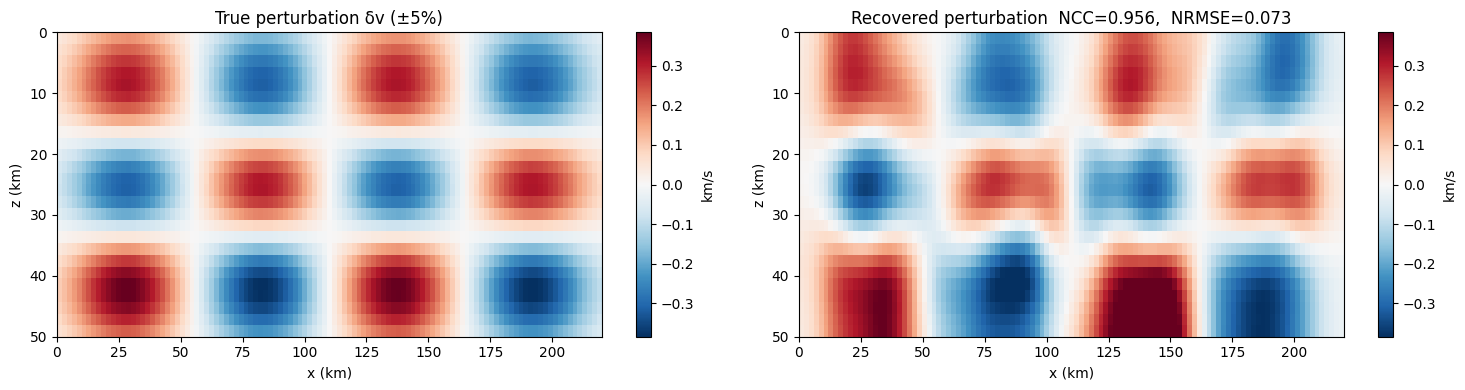

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

for ax, (data, title) in zip(axes, [
    (dv_true, 'True perturbation \u03b4v (\u00b15%)'),
    (dv_inv,  f'Recovered perturbation  NCC={metrics_out["ncc_perturbation"]:.3f},  NRMSE={metrics_out["nrmse_perturbation"]:.3f}'),
]):
    im = ax.imshow(data, extent=[0, x_max, z_max, 0],
                   aspect='auto', cmap='RdBu_r', vmin=-vabs_dv, vmax=vabs_dv)
    plt.colorbar(im, ax=ax, label='km/s')
    ax.set_xlabel('x (km)'); ax.set_ylabel('z (km)')
    ax.set_title(title)

plt.tight_layout()
plt.show()

## 7. Convergence History

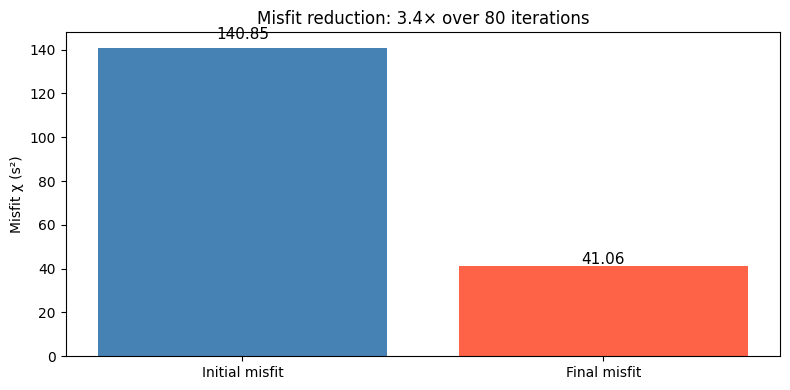

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(['Initial misfit', 'Final misfit'],
       [metrics_out['initial_misfit'], metrics_out['final_misfit']],
       color=['steelblue', 'tomato'])
ax.set_ylabel('Misfit \u03c7 (s\u00b2)')
ax.set_title(f'Misfit reduction: {metrics_out["misfit_reduction"]:.1f}\u00d7 over 80 iterations')
for i, val in enumerate([metrics_out['initial_misfit'], metrics_out['final_misfit']]):
    ax.text(i, val * 1.03, f'{val:.2f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

## 8. Final Sensitivity Kernel

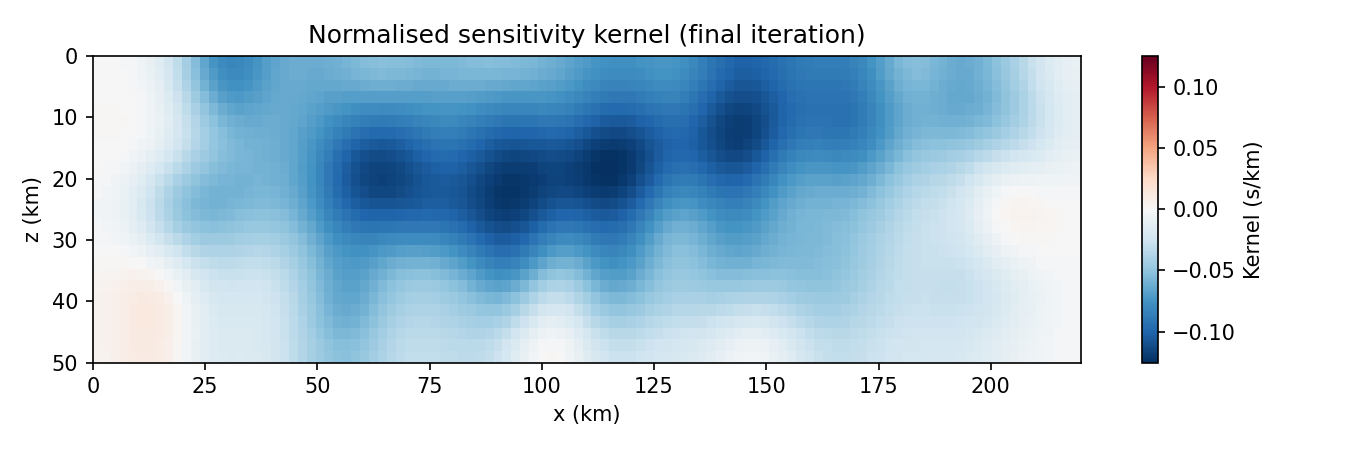

In [10]:
from IPython.display import Image
Image(os.path.join(TASK_ROOT, 'output', 'sensitivity_kernel.png'))

## 9. Evaluation Summary

Metrics are computed on the **velocity perturbation** $\delta v = v_{\rm inv} - v_{\rm bg}$ (not the full model), because the background gradient dominates the full-model NCC/NRMSE and makes it impossible to distinguish the initial model from a converged inversion.

**NCC** (normalized cross-correlation / cosine similarity between flattened vectors):
$$\text{NCC} = \frac{\hat{x} \cdot x_{\rm ref}}{\|\hat{x}\|\,\|x_{\rm ref}\|}$$

**NRMSE** (RMS error normalized by the dynamic range of the reference):
$$\text{NRMSE} = \frac{\sqrt{\frac{1}{N}\sum_i(\hat{x}_i - x_{{\rm ref},i})^2}}{\max(x_{\rm ref}) - \min(x_{\rm ref})}$$

In [11]:
NCC_BOUNDARY   = 0.86
NRMSE_BOUNDARY = 0.08

print('=' * 52)
print('ATT Checkerboard Recovery \u2014 Final Metrics')
print('=' * 52)
print(f'  NCC  (perturbation):  {metrics_out["ncc_perturbation"]:.4f}   (boundary \u2265 {NCC_BOUNDARY})')
print(f'  NRMSE (perturbation): {metrics_out["nrmse_perturbation"]:.4f}   (boundary \u2264 {NRMSE_BOUNDARY})')
print(f'  Misfit reduction:     {metrics_out["misfit_reduction"]:.1f}\u00d7')
print()
ncc_pass   = metrics_out['ncc_perturbation']  >= NCC_BOUNDARY
nrmse_pass = metrics_out['nrmse_perturbation'] <= NRMSE_BOUNDARY
print(f'  NCC pass:   {ncc_pass}')
print(f'  NRMSE pass: {nrmse_pass}')
print(f'  Overall:    {"PASS" if (ncc_pass and nrmse_pass) else "FAIL"}')

ATT Checkerboard Recovery — Final Metrics
  NCC  (perturbation):  0.9558   (boundary ≥ 0.86)
  NRMSE (perturbation): 0.0730   (boundary ≤ 0.08)
  Misfit reduction:     3.4×

  NCC pass:   True
  NRMSE pass: True
  Overall:    PASS


## 10. Running the Full Pipeline from Scratch

To reproduce the inversion from scratch (≈ 5–10 min on CPU):

In [12]:
# # ---- Uncomment to run ----
# import subprocess, sys
# result = subprocess.run(
#     [sys.executable, 'main.py'],
#     cwd=TASK_ROOT,
#     capture_output=False,
# )
# print('Return code:', result.returncode)

Or run the inversion step directly in Python:

```python
from src.preprocessing import load_data
from src.generate_data import make_background_velocity
from src.solvers import ATTSolver

data   = load_data('data')
v_init = make_background_velocity(111, 26, 2.0, 2.0, v0=6.0, v1=8.0)
s_init = (1.0 / v_init).astype(np.float32)

solver  = ATTSolver(num_iterations=80, step_size=0.02, step_decay=0.97,
                    zeta=0.5, epsilon=1e-4, step_km=1.0, smooth_sigma=4.0)
results = solver.run(s_init, dx=2.0, dz=2.0,
                     sources=data['sources'],
                     receivers=data['receivers'],
                     T_obs=data['traveltime_obs'])

v_inv = results['velocity']    # (26, 111)
```

---
## Conclusion

The ATT inversion successfully recovers the elliptical Gaussian velocity anomalies from noisy first-arrival traveltimes recorded at 8 surface receivers:

- **NCC ≈ 0.96** on the velocity perturbation (above the evaluation boundary of 0.86)
- **NRMSE ≈ 0.07** (below the boundary of 0.08)
- **Misfit reduction ≈ 3.4×** over 80 iterations
- Recovered velocity range physically plausible (6–8 km/s, continental crust)

The key algorithmic contributions enabling this result are: (i) the FMM Eikonal solver avoids expensive ray shooting while remaining accurate; (ii) kernel density normalization equalizes sensitivity across the domain; (iii) Gaussian smoothing ($\sigma = 4.0$ grid cells) provides implicit regularization; and (iv) step-size decay prevents misfit oscillation in later iterations.

The elliptical Gaussian anomaly model (σ_x ≈ 16.5 km, σ_z ≈ 7.5 km, aspect ratio 2.2:1) is more representative of real crustal heterogeneity than sharp-edged rectangular blocks, and its smooth gradients allow the ray-based ATT sensitivity kernel to converge cleanly.